In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [69]:
# Load the dataset

df = pd.read_csv("dataset_lab_1.csv")

print(df['Label'])

df['Label'].value_counts()





0             Benign
1             Benign
2             Benign
3             Benign
4             Benign
            ...     
31502    Brute Force
31503    Brute Force
31504    Brute Force
31505    Brute Force
31506    Brute Force
Name: Label, Length: 31507, dtype: str


Label
Benign         20000
DoS Hulk        5000
PortScan        5000
Brute Force     1507
Name: count, dtype: int64

(29384, 17)
0
0
Label
Benign         19240
PortScan        4849
DoS Hulk        3868
Brute Force     1427
Name: count, dtype: int64
0


Text(0.5, 1.0, 'Distribution of Flow Duration')

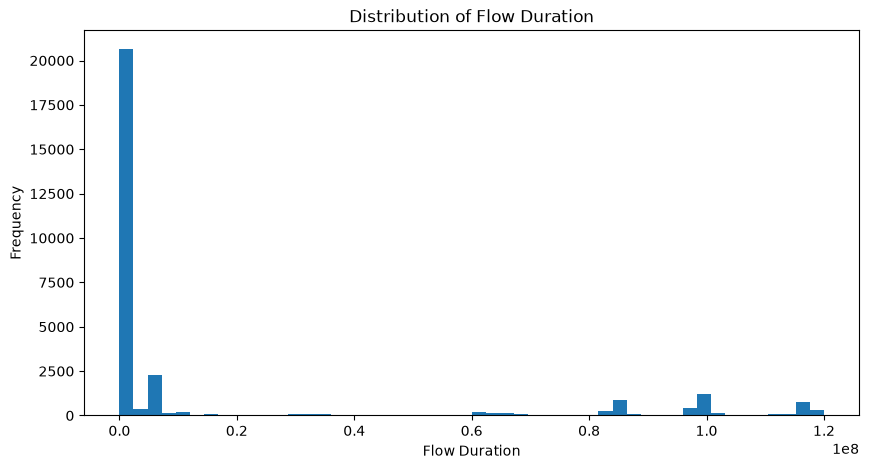

In [70]:
#CLEANING dropna, drop duplicates, drop inf, drop negative values

df = df.dropna()
df = df.drop_duplicates()
df["Label"].value_counts()
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()
cols_idx = [0, 1, 2, 3, 4, 7, 8, 9, 10, 11, 12, 14, 15]

cols = df.columns[cols_idx]

df = df[(df[cols] >= 0).all(axis=1)].copy()



print(df.shape)
print(df.isna().sum().sum())
print(df.duplicated().sum())
print(df["Label"].value_counts())
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())

# Plotting the distribution of Flow Duration
plt.figure(figsize=(10, 5))

plt.hist(df["Flow Duration"], bins=50)

plt.xlabel("Flow Duration")
plt.ylabel("Frequency")
plt.title("Distribution of Flow Duration")


In [71]:
#SPLITTED DATA + INTUITION REAGRDING CLASS CLASSIFICATION
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Label"])
Y = df["Label"]


print(df.shape)

# 70% train, 30% temporaneo
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    Y,
    test_size=0.30,
    stratify=Y,#important to keep the same distribution of classes in train and test
    random_state=42
)

# Divide il 30% in 15% validation e 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

#   Encoding the labels for training, validation, and test sets
#   metto a posto le label per il training, validation e test set

# Label Encoder da Numpy array OCIOOOO
label_encoder = LabelEncoder() 

y_train = label_encoder.fit_transform(y_train)# ocio solo fit su train
y_val = label_encoder.transform(y_val)
y_test = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)
print(label_encoder.transform(label_encoder.classes_))


(29384, 17)
(20568, 16)
(4408, 16)
(4408, 16)
Classes: ['Benign' 'Brute Force' 'DoS Hulk' 'PortScan']
[0 1 2 3]


In [72]:
## Considering the dataset is imbalanced, we can analyze the variance 
## of each feature and apply Fisher's criterion to evaluate the discriminative
## power of each feature for classification.

# STATS TO UNDERSTAND THE DATASET

#variance by feature
variances = X_train.var().sort_values(ascending=False)
print(variances)

# Fisher's ish Criterion
print("\nFisher's Criterion")
scores = {}

for label in np.unique(y_train):

    X_class = X_train[y_train == label]
    X_rest  = X_train[y_train != label]

    mean_class = X_class.mean()
    mean_rest = X_rest.mean()

    var_class = X_class.var()
    var_rest = X_rest.var()

    fisher = (mean_class - mean_rest)**2 / (
        var_class + var_rest + 1e-9
    )

    scores[label] = fisher.mean()

scores = pd.Series(scores).sort_values()

print("0 = Benign, 1 = Brute Force, 2 = DoS Hulk, 3 = PortScan")
print(scores, "\n\nThe higher the score, the more discriminative the feature is for classification.")

Flow Duration             1.317755e+15
Flow Bytes/s              6.975741e+14
Fwd IAT Std               1.500167e+14
Flow IAT Mean             1.903953e+13
Flow Packets/s            3.648223e+10
Destination Port          3.104833e+08
Bwd Packet Length Max     4.038559e+06
Bwd Packet Length Mean    3.843754e+05
Fwd Packet Length Max     2.327037e+05
Packet Length Mean        8.741098e+04
Fwd Packet Length Mean    1.335118e+04
Subflow Fwd Packets       1.354483e+03
Total Fwd Packets         1.354483e+03
Down/Up Ratio             2.752730e-01
SYN Flag Count            3.890614e-02
Fwd PSH Flags             3.890614e-02
dtype: float64

Fisher's Criterion
0 = Benign, 1 = Brute Force, 2 = DoS Hulk, 3 = PortScan
0    0.092924
1    0.142394
3    0.170629
2    1.046245
dtype: float64 

The higher the score, the more discriminative the feature is for classification.


In [73]:
# Proporzioni
print("\nTrain")

print(pd.Series(y_train).value_counts(normalize=True))

print("\nValidation")
print(pd.Series(y_val).value_counts(normalize=True))

print("\nTest")
print(pd.Series(y_test) .value_counts(normalize=True))


Train
0    0.654755
3    0.165014
2    0.131661
1    0.048571
Name: proportion, dtype: float64

Validation
0    0.654719
3    0.165154
2    0.131579
1    0.048548
Name: proportion, dtype: float64

Test
0    0.654946
3    0.164927
2    0.131579
1    0.048548
Name: proportion, dtype: float64


In [74]:
# Standardization of the dataset SCALER

from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()

X_train_std = scaler_std.fit_transform(X_train)
X_val_std = scaler_std.transform(X_val)
X_test_std = scaler_std.transform(X_test)

In [75]:

## LOG MIGLIORA LA DISITRIBUZIONE, EVENTUALI DROWBACK ?????
## LOG + SCALER (NON USATO ATTUALMENTE)

import numpy as np
from sklearn.preprocessing import StandardScaler

X_train_log = X_train.copy()
X_val_log = X_val.copy()
X_test_log = X_test.copy()

X_train_log["Flow Duration"] = np.log1p(X_train_log["Flow Duration"])
X_val_log["Flow Duration"] = np.log1p(X_val_log["Flow Duration"])
X_test_log["Flow Duration"] = np.log1p(X_test_log["Flow Duration"])

scaler_log = StandardScaler()

X_train_log_scaled = scaler_log.fit_transform(X_train_log)
X_val_log_scaled = scaler_log.transform(X_val_log)
X_test_log_scaled = scaler_log.transform(X_test_log)

### Plot of The Differnce between the 2 Scaler (Normal Used as of now)

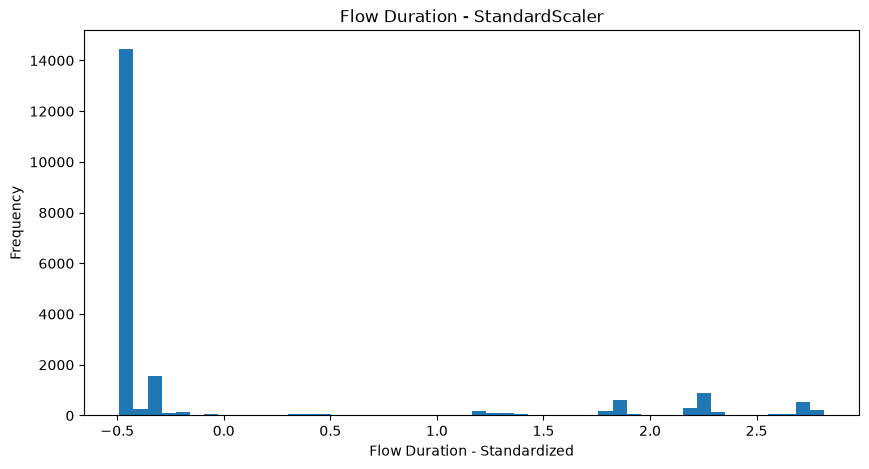

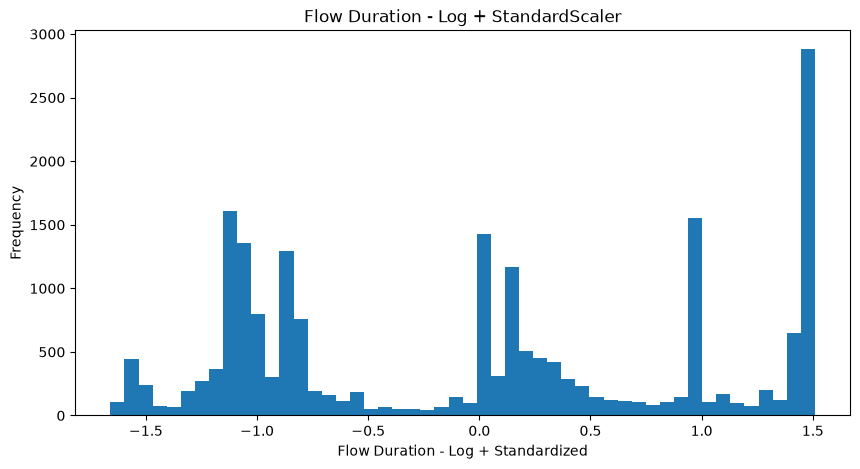

In [76]:
# Plotting the distribution of Flow Duration after 
# Standardization and Log + Standardization

import matplotlib.pyplot as plt

flow_idx = X_train.columns.get_loc("Flow Duration")

plt.figure(figsize=(10, 5))
plt.hist(X_train_std[:, flow_idx], bins=50)
plt.xlabel("Flow Duration - Standardized")
plt.ylabel("Frequency")
plt.title("Flow Duration - StandardScaler")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(X_train_log_scaled[:, flow_idx], bins=50)
plt.xlabel("Flow Duration - Log + Standardized")
plt.ylabel("Frequency")
plt.title("Flow Duration - Log + StandardScaler")
plt.show()

In [77]:
#
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


# HYPERPARAMETERS

BATCH_SIZE = 64
HIDDEN_SIZE = 64
LEARNING_RATE = 5e-4
#WEIGHT_DECAY = 1e-4

MAX_EPOCHS = 100
PATIENCE = 20
MIN_DELTA = 1e-4

NUM_CLASSES = 4
OUTPUT_SIZE = NUM_CLASSES

# Number of input features tutte le colonne del dataset tranne la label
INPUT_SIZE = 16

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)



Device: cpu


In [ ]:
# Network
class FFNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(FFNN, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x




# Initialize model
model = FFNN(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    output_size=OUTPUT_SIZE
)
# Valori iniziali dei pesi e bias
print(model.fc1.weight.shape)
print(model.fc1.bias.shape)

# Loss
criterion = nn.CrossEntropyLoss()


# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

torch.Size([64, 16])
torch.Size([64]) tensor(-0.1430, grad_fn=<SelectBackward0>)


In [83]:
# Convert data to PyTorch tensors 
# Note that torch tensors use, by default, 
# float32 (single precision) data type. NumPy, instead, defaults to float64 (double precision).
# This happens for performance-related reasons: float32 operations are faster than float64.





X_train_tensor = torch.tensor(X_train.to_numpy(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val.to_numpy(), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test.to_numpy(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


# check the shape of the tensors
print("X_train_tensor shape:", X_train_tensor.shape)

X_train_tensor shape: torch.Size([20568, 16])


In [ ]:
## DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

validation_dataset = TensorDataset(X_val_tensor, y_val_tensor)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)



In [89]:
## DA VEDERE INSIEME HO MESSO ERRORI COSì NON SI RUNNA




num_epochs = 100

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # ========================
    # TRAINING
    # ========================

    model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_dataset)


    # ========================
    # VALIDATION
    # ========================

    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in vali_loader:

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(validation_dataset)


    tin_losses.append(train_loss)
    val_losses.append(val_ss)


    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

NameError: name 'vali_loader' is not defined